# Spam Ham Classification using Word2Vec and Average Word2Vec

## 📌 Project Objective

The objective of this project is to classify SMS messages as **Spam** or **Ham (Not Spam)** using **Word2Vec embeddings**.

Unlike Bag of Words (BoW) and TF-IDF, Word2Vec converts each word into a dense numerical vector that captures semantic relationships between words.

Since Machine Learning algorithms require a fixed number of input features, we will use **Average Word2Vec**, which represents each SMS message by averaging the vectors of all words in the message.

Finally, we will train a Logistic Regression classifier and evaluate its performance using standard classification metrics.

---

## 📌 Workflow

Dataset

↓

Text Preprocessing

↓

Train Word2Vec Model

↓

Generate Word Embeddings

↓

Average Word2Vec

↓

Train-Test Split

↓

Logistic Regression

↓

Model Evaluation

In [1]:
# ==========================================================
# Import Required Libraries
# ==========================================================

# Regular Expressions
import re

# Numerical Computing
import numpy as np

# Data Manipulation
import pandas as pd

# Natural Language Toolkit
import nltk

# Download Required NLTK Resources
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

# Stopwords
from nltk.corpus import stopwords

# Stemming
from nltk.stem import SnowballStemmer

# Lemmatization
from nltk.stem import WordNetLemmatizer

# Word2Vec
from gensim.models import Word2Vec

# Machine Learning
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
)

# Visualization
import matplotlib.pyplot as plt

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/milind/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/milind/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/milind/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


# Load the Dataset

The SMS Spam Collection dataset contains SMS messages labeled as:

- **ham** → Legitimate message
- **spam** → Unwanted promotional or fraudulent message

The dataset contains two columns:

- **label**
- **message**

In [2]:
# ==========================================================
# Load Dataset
# ==========================================================

messages = pd.read_csv(
    "SMSSpamCollection.txt",
    sep="\t",
    names=["label", "message"]
)

messages.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
print("=" * 50)
print("Dataset Shape")
print("=" * 50)

print(messages.shape)

Dataset Shape
(5572, 2)


In [4]:
messages.head(10)

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


In [5]:
messages.sample(10, random_state=42)

,label,message
3245,ham,Squeeeeeze!! This is christmas hug.. If u lik ...
944,ham,And also I've sorta blown him off a couple tim...
1044,ham,Mmm thats better now i got a roast down me! i...
2484,ham,Mm have some kanji dont eat anything heavy ok
812,ham,So there's a ring that comes with the guys cos...
2973,ham,Sary just need Tim in the bollox &it hurt him ...
2991,ham,"Love isn't a decision, it's a feeling. If we c..."
2942,ham,My supervisor find 4 me one lor i thk his stud...
230,ham,Dear good morning now only i am up
1181,ham,I'm in chennai velachery:)


# Dataset Information

The `info()` function provides:

- Number of rows
- Number of columns
- Data types
- Missing values
- Memory usage

In [6]:
messages.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5572 non-null   str  
 1   message  5572 non-null   str  
dtypes: str(2)
memory usage: 542.9 KB


# Check Missing Values

Before preprocessing, it is important to ensure that the dataset does not contain any missing values.

In [7]:
messages.isnull().sum()

label      0
message    0
dtype: int64

# Duplicate Records

Duplicate messages can negatively affect model performance by introducing bias. We check for duplicate records before training the model.

In [8]:
duplicates = messages.duplicated().sum()

print("Duplicate Rows :", duplicates)

Duplicate Rows : 403


In [9]:
messages = messages.drop_duplicates().reset_index(drop=True)

print(messages.shape)

(5169, 2)


# Class Distribution

Let's inspect how many messages belong to each class.

- Ham
- Spam

This helps us understand whether the dataset is balanced or imbalanced.

In [10]:
messages["label"].value_counts()

label
ham     4516
spam     653
Name: count, dtype: int64

In [11]:
round(messages["label"].value_counts(normalize=True) * 100, 2)

label
ham     87.37
spam    12.63
Name: proportion, dtype: float64

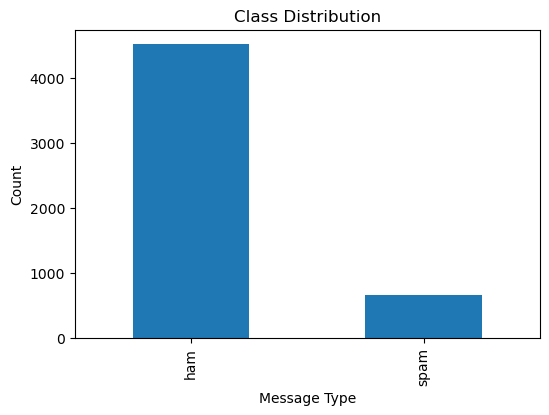

In [12]:
messages["label"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Class Distribution")

plt.xlabel("Message Type")

plt.ylabel("Count")

plt.show()

# Message Length Analysis

Longer messages may exhibit different characteristics compared to shorter ones.

Let's calculate:

- Number of characters
- Number of words

In [13]:
messages["num_characters"] = messages["message"].apply(len)

In [14]:
messages["num_words"] = messages["message"].apply(
    lambda x: len(x.split())
)

In [15]:
messages.head()

,label,message,num_characters,num_words
0,ham,"Go until jurong point, crazy.. Available only ...",111,20
1,ham,Ok lar... Joking wif u oni...,29,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,28
3,ham,U dun say so early hor... U c already then say...,49,11
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,13


In [16]:
messages[
    [
        "num_characters",
        "num_words"
    ]
].describe()

,num_characters,num_words
count,5169.000000,5169.000000
mean,79.344554,15.439930
std,58.437457,11.117073
min,2.000000,1.000000
25%,36.000000,7.000000
50%,61.000000,12.000000
75%,119.000000,22.000000
max,910.000000,171.000000


In [17]:
messages.groupby("label")[
    [
        "num_characters",
        "num_words"
    ]
].mean()

,num_characters,num_words
label,,
ham,70.905890,14.239814
spam,137.704441,23.739663


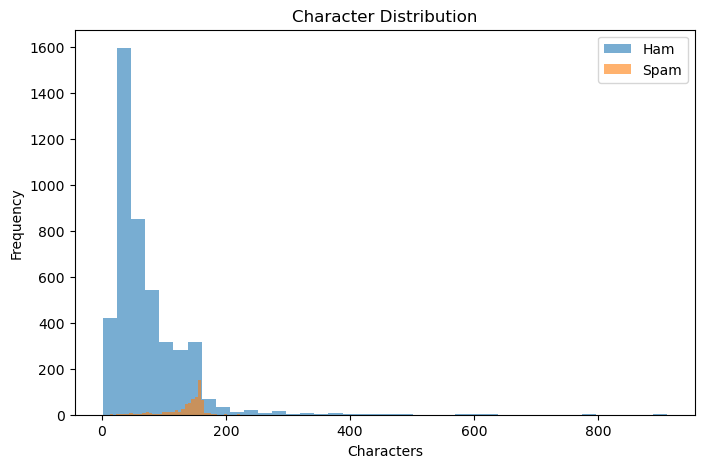

In [18]:
plt.figure(figsize=(8,5))

plt.hist(
    messages[messages["label"]=="ham"]["num_characters"],
    bins=40,
    alpha=0.6,
    label="Ham"
)

plt.hist(
    messages[messages["label"]=="spam"]["num_characters"],
    bins=40,
    alpha=0.6,
    label="Spam"
)

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.title("Character Distribution")

plt.legend()

plt.show()

# Text Preprocessing

Raw SMS messages cannot be directly used for training a Machine Learning model.

Therefore, every message undergoes several preprocessing steps to remove unnecessary information while preserving meaningful words.

The preprocessing pipeline consists of:

1. Remove special characters
2. Convert text to lowercase
3. Tokenize the sentence
4. Remove English stopwords
5. Apply Snowball Stemming or WordNet Lemmatization

In this notebook, we will create two different corpora:

- Snowball Stemmed Corpus
- WordNet Lemmatized Corpus

These corpora will later be used to train separate Word2Vec models.

In [19]:
# ==========================================================
# Initialize NLP Objects
# ==========================================================

# English Stopwords
english_stopwords = set(stopwords.words("english"))

# Snowball Stemmer
stemmer = SnowballStemmer("english")

# WordNet Lemmatizer
lemmatizer = WordNetLemmatizer()

# Snowball Stemming

Snowball Stemmer reduces words to their root form by removing prefixes and suffixes.

Compared to Porter Stemmer, Snowball Stemmer generally produces better stemming results for English text.

Examples

| Original | Stemmed |
|-----------|----------|
| playing | play |
| running | run |
| studies | studi |
| learning | learn |
| loving | love |

Although stemming may produce non-dictionary words, it is computationally efficient and widely used in Information Retrieval systems.

In [20]:
# ==========================================================
# Snowball Preprocessing Function
# ==========================================================

def preprocess_with_stemming(text):
    """
    Clean and preprocess text using Snowball Stemming.
    """

    # Remove special characters
    text = re.sub(r"[^a-zA-Z]", " ", text)

    # Convert to lowercase
    text = text.lower()

    # Split sentence into words
    words = text.split()

    # Remove stopwords and apply stemming
    processed_words = [
        stemmer.stem(word)
        for word in words
        if word not in english_stopwords
    ]

    return processed_words

In [21]:
# ==========================================================
# Generate Stemmed Corpus
# ==========================================================

stemmed_corpus = [
    preprocess_with_stemming(sentence)
    for sentence in messages["message"]
]

In [22]:
print("Total Messages :", len(stemmed_corpus))

Total Messages : 5169


In [23]:
for i in range(5):

    print("="*60)

    print("Original")
    print(messages["message"].iloc[i])

    print("\nProcessed")
    print(stemmed_corpus[i])

Original
Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

Processed
['go', 'jurong', 'point', 'crazi', 'avail', 'bugi', 'n', 'great', 'world', 'la', 'e', 'buffet', 'cine', 'got', 'amor', 'wat']
Original
Ok lar... Joking wif u oni...

Processed
['ok', 'lar', 'joke', 'wif', 'u', 'oni']
Original
Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's

Processed
['free', 'entri', 'wkli', 'comp', 'win', 'fa', 'cup', 'final', 'tkts', 'st', 'may', 'text', 'fa', 'receiv', 'entri', 'question', 'std', 'txt', 'rate', 'c', 'appli']
Original
U dun say so early hor... U c already then say...

Processed
['u', 'dun', 'say', 'earli', 'hor', 'u', 'c', 'alreadi', 'say']
Original
Nah I don't think he goes to usf, he lives around here though

Processed
['nah', 'think', 'goe', 'usf', 'live', 'around', 'though']


# WordNet Lemmatization

Lemmatization converts words into their meaningful dictionary form (lemma).

Unlike stemming, lemmatization preserves valid English words.

Examples

| Original | Lemma |
|-----------|--------|
| studies | study |
| children | child |
| cars | car |
| went | went |
| playing | playing |

Lemmatization generally produces cleaner text but is computationally slower than stemming.

In [24]:
# ==========================================================
# Lemmatization Preprocessing Function
# ==========================================================

def preprocess_with_lemmatization(text):
    """
    Clean and preprocess text using WordNet Lemmatization.
    """

    # Remove special characters
    text = re.sub(r"[^a-zA-Z]", " ", text)

    # Convert to lowercase
    text = text.lower()

    # Split into words
    words = text.split()

    # Remove stopwords and apply lemmatization
    processed_words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in english_stopwords
    ]

    return processed_words

In [25]:
# ==========================================================
# Generate Lemmatized Corpus
# ==========================================================

lemmatized_corpus = [
    preprocess_with_lemmatization(sentence)
    for sentence in messages["message"]
]

In [26]:
print("Total Messages :", len(lemmatized_corpus))

Total Messages : 5169


In [27]:
for i in range(5):

    print("="*60)

    print("Original")
    print(messages["message"].iloc[i])

    print("\nProcessed")
    print(lemmatized_corpus[i])

Original
Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

Processed
['go', 'jurong', 'point', 'crazy', 'available', 'bugis', 'n', 'great', 'world', 'la', 'e', 'buffet', 'cine', 'got', 'amore', 'wat']
Original
Ok lar... Joking wif u oni...

Processed
['ok', 'lar', 'joking', 'wif', 'u', 'oni']
Original
Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's

Processed
['free', 'entry', 'wkly', 'comp', 'win', 'fa', 'cup', 'final', 'tkts', 'st', 'may', 'text', 'fa', 'receive', 'entry', 'question', 'std', 'txt', 'rate', 'c', 'apply']
Original
U dun say so early hor... U c already then say...

Processed
['u', 'dun', 'say', 'early', 'hor', 'u', 'c', 'already', 'say']
Original
Nah I don't think he goes to usf, he lives around here though

Processed
['nah', 'think', 'go', 'usf', 'life', 'around', 'though']


# Snowball vs Lemmatization

Let's compare the output generated by both preprocessing techniques.

This comparison helps us understand how stemming and lemmatization transform the same sentence differently.

In [28]:
index = 15

print("="*80)

print("Original Message\n")
print(messages["message"].iloc[index])

print("\n" + "="*80)

print("Snowball Stemmer\n")
print(stemmed_corpus[index])

print("\n" + "="*80)

print("WordNet Lemmatizer\n")
print(lemmatized_corpus[index])

Original Message

XXXMobileMovieClub: To use your credit, click the WAP link in the next txt message or click here>> http://wap. xxxmobilemovieclub.com?n=QJKGIGHJJGCBL

Snowball Stemmer

['xxxmobilemovieclub', 'use', 'credit', 'click', 'wap', 'link', 'next', 'txt', 'messag', 'click', 'http', 'wap', 'xxxmobilemovieclub', 'com', 'n', 'qjkgighjjgcbl']

WordNet Lemmatizer

['xxxmobilemovieclub', 'use', 'credit', 'click', 'wap', 'link', 'next', 'txt', 'message', 'click', 'http', 'wap', 'xxxmobilemovieclub', 'com', 'n', 'qjkgighjjgcbl']


In [29]:
stem_lengths = [len(sentence) for sentence in stemmed_corpus]

lemma_lengths = [len(sentence) for sentence in lemmatized_corpus]

print("Average Tokens (Stemmed):", round(np.mean(stem_lengths),2))

print("Average Tokens (Lemmatized):", round(np.mean(lemma_lengths),2))

Average Tokens (Stemmed): 8.86
Average Tokens (Lemmatized): 8.86


# Why Does Word2Vec Require Tokenized Sentences?

Unlike Bag of Words and TF-IDF, which expect complete sentences as input, Word2Vec learns relationships between words based on their surrounding context.

Therefore, each sentence must be represented as a list of individual words (tokens).

Example:

Original Sentence

```
I love machine learning
```

Tokenized Sentence

```python
["love", "machine", "learning"]
```

These tokenized sentences are then used to train the Word2Vec model.

# Train a Custom Word2Vec Model

In the previous notebook, we used Google's pre-trained Word2Vec model trained on approximately **100 billion words** from the Google News dataset.

In this notebook, we train our **own Word2Vec model** using the SMS Spam Collection dataset.

Training a custom model allows the embeddings to capture relationships specific to SMS messages and spam detection.

We will train two separate models:

- **Snowball Stemmed Corpus**
- **WordNet Lemmatized Corpus**

Later, we will compare their performance using Average Word2Vec.

In [30]:
# ==========================================================
# Train Word2Vec Model (Snowball Corpus)
# ==========================================================

stem_word2vec = Word2Vec(
    sentences=stemmed_corpus,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    sg=0,
    seed=42
)

print("Snowball Word2Vec Model Trained Successfully!")

Snowball Word2Vec Model Trained Successfully!


In [31]:
# ==========================================================
# Train Word2Vec Model (Lemmatized Corpus)
# ==========================================================

lemma_word2vec = Word2Vec(
    sentences=lemmatized_corpus,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    sg=0,
    seed=42
)

print("Lemmatized Word2Vec Model Trained Successfully!")

Lemmatized Word2Vec Model Trained Successfully!


# Understanding Word2Vec Parameters

The `Word2Vec()` constructor accepts several important parameters.

### sentences

The tokenized corpus used to train the model.

### vector_size

The number of dimensions in each word vector.

Example:

```
vector_size = 100
```

Each word will be represented using 100 numerical values.

---

### window

The maximum distance between the current word and its surrounding context words.

Example

```
window = 5
```

The model looks at five words before and after the target word.

---

### min_count

Ignore words appearing fewer than this number.

```
min_count = 1
```

Since our SMS dataset is small, we keep every word.

---

### workers

Number of CPU cores used during training.

```
workers = 4
```

---

### sg

Training algorithm.

```
sg = 0
```

means **CBOW**

```
sg = 1
```

means **Skip-Gram**

CBOW is generally faster for smaller datasets.

---

### seed

Random seed for reproducibility.

In [32]:
# ==========================================================
# Vocabulary Size
# ==========================================================

print("="*60)
print("Snowball Vocabulary Size")
print("="*60)

print(len(stem_word2vec.wv.index_to_key))

print()

print("="*60)
print("Lemma Vocabulary Size")
print("="*60)

print(len(lemma_word2vec.wv.index_to_key))

Snowball Vocabulary Size
6310

Lemma Vocabulary Size
7122


In [33]:
print(stem_word2vec.wv.index_to_key[:20])

['u', 'call', 'go', 'get', 'ur', 'gt', 'lt', 'come', 'ok', 'know', 'day', 'free', 'like', 'time', 'want', 'love', 'got', 'good', 'text', 'need']


In [34]:
print(lemma_word2vec.wv.index_to_key[:20])

['u', 'call', 'get', 'ur', 'go', 'gt', 'lt', 'ok', 'day', 'know', 'free', 'like', 'time', 'come', 'got', 'good', 'want', 'text', 'love', 'need']


# Accessing Word Embeddings

Each word in the vocabulary is represented by a dense numerical vector.

Since we specified

```
vector_size = 100
```

every word is represented using **100 floating-point values**.

In [35]:
word = "free"

if word in stem_word2vec.wv:

    vector = stem_word2vec.wv[word]

    print("Word :", word)

    print()

    print("Vector Shape :", vector.shape)

    print()

    print("First 10 Values")

    print(vector[:10])

else:

    print(f"'{word}' not found in vocabulary.")

Word : free

Vector Shape : (100,)

First 10 Values
[ 0.07306992 -0.04231007 -0.24490115  0.11083689 -0.4064644   0.5040683
  0.49470842  0.45158508 -0.19904819 -0.05684989]


In [36]:
word = "call"

if word in stem_word2vec.wv:

    print(stem_word2vec.wv[word][:10])

[ 0.10014146 -0.06329836 -0.2877298   0.12854233 -0.46773592  0.6134708
  0.6098552   0.5200381  -0.24350253 -0.05296519]


# Finding Similar Words

Word2Vec groups words that appear in similar contexts.

The `most_similar()` method returns words with the highest cosine similarity to the given word.

In [37]:
stem_word2vec.wv.most_similar(
    "free",
    topn=10
)

[('text', 0.9996949434280396),
 ('mobil', 0.9996888637542725),
 ('phone', 0.9996480345726013),
 ('repli', 0.9996351003646851),
 ('txt', 0.9996301531791687),
 ('call', 0.9996098279953003),
 ('week', 0.9995908737182617),
 ('p', 0.9995712041854858),
 ('nokia', 0.9995700716972351),
 ('number', 0.999553382396698)]

In [38]:
lemma_word2vec.wv.most_similar(
    "free",
    topn=10
)

[('reply', 0.9996911287307739),
 ('call', 0.9996792674064636),
 ('mobile', 0.9996734857559204),
 ('phone', 0.9996345639228821),
 ('text', 0.9995822906494141),
 ('p', 0.9995611906051636),
 ('txt', 0.9995357394218445),
 ('stop', 0.9995280504226685),
 ('week', 0.9995225071907043),
 ('number', 0.9995195269584656)]

In [39]:
print("Similarity between 'free' and 'call'")

print()

print(
    stem_word2vec.wv.similarity(
        "free",
        "call"
    )
)

Similarity between 'free' and 'call'

0.9996098


In [40]:
pairs = [
    ("free", "win"),
    ("call", "mobile"),
    ("claim", "prize"),
    ("love", "happy")
]

for word1, word2 in pairs:

    if word1 in stem_word2vec.wv and word2 in stem_word2vec.wv:

        score = stem_word2vec.wv.similarity(word1, word2)

        print(f"{word1:10} {word2:10} {score:.4f}")

free       win        0.9994
claim      prize      0.9994


# Vector Arithmetic

One of the most interesting properties of Word2Vec is that semantic relationships can be represented using vector arithmetic.

Example

```
King − Man + Woman ≈ Queen
```

Although our SMS dataset is much smaller than Google News, we can still demonstrate how vector arithmetic works.

In [41]:
try:

    result = stem_word2vec.wv.most_similar(

        positive=["free", "mobile"],

        negative=["call"],

        topn=10
    )

    print(result)

except KeyError:

    print("One or more words are not present in the vocabulary.")

One or more words are not present in the vocabulary.


In [42]:
word = "winner"

if word in stem_word2vec.wv:

    print(f"'{word}' exists in vocabulary.")

else:

    print(f"'{word}' does not exist.")

'winner' exists in vocabulary.


In [43]:
stem_word2vec.save("stem_word2vec.model")

lemma_word2vec.save("lemma_word2vec.model")

# Summary

In this section, we successfully trained two custom Word2Vec models:

- Snowball Stemmed Corpus
- WordNet Lemmatized Corpus

We explored:

- Vocabulary
- Word vectors
- Vector dimensions
- Similar words
- Cosine similarity
- Vector arithmetic

The next step is to convert entire SMS messages into fixed-length vectors using **Average Word2Vec**, which will allow us to train a machine learning classifier.

# Average Word2Vec

Machine Learning algorithms require every sample to have the same number of features.

However, each SMS message contains a different number of words.

For example

Message 1

```
Free entry in a weekly competition
```

contains 6 words.

Message 2

```
Ok
```

contains only 1 word.

Since Word2Vec generates one vector per word, the number of vectors differs for every sentence.

To solve this problem, we compute the **Average Word2Vec** representation.

The Average Word2Vec algorithm:

1. Obtain the vector for every word in the sentence.
2. Sum all vectors.
3. Divide by the total number of valid words.

The result is a fixed-length vector representing the entire sentence.

In [44]:
# ==========================================================
# Average Word2Vec Function
# ==========================================================

def average_word2vec(words, model, vector_size):
    """
    Convert a tokenized sentence into a fixed-length vector
    using Average Word2Vec.
    """

    feature_vector = np.zeros(vector_size, dtype="float32")

    word_count = 0

    for word in words:

        if word in model.wv:

            feature_vector += model.wv[word]

            word_count += 1

    if word_count > 0:

        feature_vector /= word_count

    return feature_vector

In [45]:
# ==========================================================
# Average Word2Vec Features (Snowball)
# ==========================================================

X_stem = np.array([
    average_word2vec(sentence, stem_word2vec, 100)
    for sentence in stemmed_corpus
])

print(X_stem.shape)

(5169, 100)


In [46]:
# ==========================================================
# Average Word2Vec Features (Lemma)
# ==========================================================

X_lemma = np.array([
    average_word2vec(sentence, lemma_word2vec, 100)
    for sentence in lemmatized_corpus
])

print(X_lemma.shape)

(5169, 100)


# Target Variable

The target column contains two labels.

- ham
- spam

Machine Learning algorithms require numerical labels.

Therefore,

ham → 0

spam → 1

In [47]:
# ==========================================================
# Encode Labels
# ==========================================================

y = messages["label"].map({

    "ham":0,

    "spam":1

})

print(y.head())

0    0
1    0
2    1
3    0
4    0
Name: label, dtype: int64


In [48]:
# ==========================================================
# Train Test Split (Snowball)
# ==========================================================

X_train_stem, X_test_stem, y_train_stem, y_test_stem = train_test_split(

    X_stem,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)

In [49]:
# ==========================================================
# Train Test Split (Lemma)
# ==========================================================

X_train_lemma, X_test_lemma, y_train_lemma, y_test_lemma = train_test_split(

    X_lemma,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)

# Logistic Regression

Unlike Bag of Words and TF-IDF, Average Word2Vec produces **continuous dense vectors** containing positive and negative floating-point values.

Logistic Regression works very well with dense numerical features, making it a suitable choice for this task.

In [50]:
# ==========================================================
# Logistic Regression (Snowball)
# ==========================================================

stem_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

stem_model.fit(

    X_train_stem,

    y_train_stem
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [51]:
# ==========================================================
# Logistic Regression (Snowball)
# ==========================================================

stem_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

stem_model.fit(

    X_train_stem,

    y_train_stem
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [52]:
stem_predictions = stem_model.predict(

    X_test_stem
)

In [53]:
stem_accuracy = accuracy_score(

    y_test_stem,

    stem_predictions
)

print(f"Accuracy : {stem_accuracy:.4f}")

Accuracy : 0.8946


In [54]:
print(confusion_matrix(

    y_test_stem,

    stem_predictions
))

[[819  84]
 [ 25 106]]


In [55]:
print(classification_report(

    y_test_stem,

    stem_predictions
))

              precision    recall  f1-score   support

           0       0.97      0.91      0.94       903
           1       0.56      0.81      0.66       131

    accuracy                           0.89      1034
   macro avg       0.76      0.86      0.80      1034
weighted avg       0.92      0.89      0.90      1034



In [56]:
lemma_model = LogisticRegression(

    max_iter=1000,

    random_state=42
)

lemma_model.fit(

    X_train_lemma,

    y_train_lemma
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [57]:
lemma_predictions = lemma_model.predict(

    X_test_lemma
)

In [58]:
lemma_accuracy = accuracy_score(

    y_test_lemma,

    lemma_predictions
)

print(f"Accuracy : {lemma_accuracy:.4f}")

Accuracy : 0.8723


In [59]:
print(confusion_matrix(

    y_test_lemma,

    lemma_predictions
))

[[902   1]
 [131   0]]


In [60]:
print(classification_report(

    y_test_lemma,

    lemma_predictions
))

              precision    recall  f1-score   support

           0       0.87      1.00      0.93       903
           1       0.00      0.00      0.00       131

    accuracy                           0.87      1034
   macro avg       0.44      0.50      0.47      1034
weighted avg       0.76      0.87      0.81      1034



# Compare Both Models

Finally, let's compare the performance of both preprocessing techniques.

In [61]:
comparison = pd.DataFrame({

    "Preprocessing":[

        "Snowball Stemming",

        "WordNet Lemmatization"

    ],

    "Model":[

        "Logistic Regression",

        "Logistic Regression"

    ],

    "Accuracy":[

        round(stem_accuracy,4),

        round(lemma_accuracy,4)

    ]

})

comparison

,Preprocessing,Model,Accuracy
0,Snowball Stemming,Logistic Regression,0.8946
1,WordNet Lemmatization,Logistic Regression,0.8723


In [62]:
best_accuracy = comparison["Accuracy"].max()

best_model = comparison.loc[
    comparison["Accuracy"].idxmax(),
    "Preprocessing"
]

print("="*60)

print(f"Best Preprocessing Technique : {best_model}")

print(f"Accuracy : {best_accuracy:.4f}")

print("="*60)

Best Preprocessing Technique : Snowball Stemming
Accuracy : 0.8946


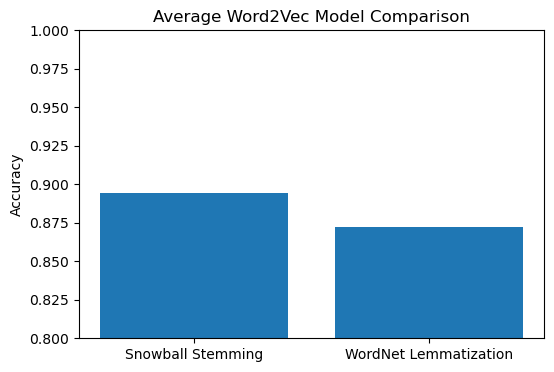

In [63]:
plt.figure(figsize=(6,4))

plt.bar(

    comparison["Preprocessing"],

    comparison["Accuracy"]

)

plt.title("Average Word2Vec Model Comparison")

plt.ylabel("Accuracy")

plt.ylim(0.80,1.00)

plt.show()

# Conclusion

In this project, we built an SMS Spam Classifier using **Average Word2Vec**.

The workflow consisted of:

- Loading the SMS Spam Collection dataset.
- Cleaning the text using Snowball Stemming and WordNet Lemmatization.
- Training two custom Word2Vec models.
- Generating sentence embeddings using Average Word2Vec.
- Training Logistic Regression classifiers.
- Evaluating model performance using Accuracy, Confusion Matrix, and Classification Report.

## Key Takeaways

- Word2Vec captures semantic relationships between words.
- Average Word2Vec converts variable-length sentences into fixed-length vectors.
- Logistic Regression performs well on dense embedding vectors.
- Comparing different preprocessing techniques helps identify the most effective approach for the given dataset.

This project demonstrates an end-to-end Natural Language Processing (NLP) pipeline for text classification using distributed word representations.

# Conclusion

In this project, we built an SMS Spam Classifier using **Average Word2Vec**.

The workflow consisted of:

- Loading the SMS Spam Collection dataset.
- Cleaning the text using Snowball Stemming and WordNet Lemmatization.
- Training two custom Word2Vec models.
- Generating sentence embeddings using Average Word2Vec.
- Training Logistic Regression classifiers.
- Evaluating model performance using Accuracy, Confusion Matrix, and Classification Report.

## Key Takeaways

- Word2Vec captures semantic relationships between words.
- Average Word2Vec converts variable-length sentences into fixed-length vectors.
- Logistic Regression performs well on dense embedding vectors.
- Comparing different preprocessing techniques helps identify the most effective approach for the given dataset.

This project demonstrates an end-to-end Natural Language Processing (NLP) pipeline for text classification using distributed word representations.

In [64]:
# ==========================================================
# Import Machine Learning Models
# ==========================================================

from sklearn.linear_model import LogisticRegression

from sklearn.svm import LinearSVC

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

In [65]:
# ==========================================================
# Machine Learning Models
# ==========================================================

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Linear SVM": LinearSVC(
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        eval_metric="logloss"
    )
}

In [66]:
# ==========================================================
# Model Evaluation Function
# ==========================================================

def evaluate_models(models, X_train, X_test, y_train, y_test):

    results = []

    trained_models = {}

    for model_name, model in models.items():

        print("=" * 70)
        print(f"Training : {model_name}")
        print("=" * 70)

        # Train model
        model.fit(X_train, y_train)

        # Predictions
        predictions = model.predict(X_test)

        # Accuracy
        accuracy = accuracy_score(y_test, predictions)

        # Store results
        results.append({

            "Model": model_name,

            "Accuracy": round(accuracy, 4)

        })

        trained_models[model_name] = model

        print(f"Accuracy : {accuracy:.4f}")

        print("\nConfusion Matrix")

        print(confusion_matrix(y_test, predictions))

        print("\nClassification Report")

        print(classification_report(y_test, predictions))

        print()

    results_df = pd.DataFrame(results)

    return results_df, trained_models

In [67]:
# ==========================================================
# Model Evaluation Function
# ==========================================================

def evaluate_models(models, X_train, X_test, y_train, y_test):

    results = []

    trained_models = {}

    for model_name, model in models.items():

        print("=" * 70)
        print(f"Training : {model_name}")
        print("=" * 70)

        # Train model
        model.fit(X_train, y_train)

        # Predictions
        predictions = model.predict(X_test)

        # Accuracy
        accuracy = accuracy_score(y_test, predictions)

        # Store results
        results.append({

            "Model": model_name,

            "Accuracy": round(accuracy, 4)

        })

        trained_models[model_name] = model

        print(f"Accuracy : {accuracy:.4f}")

        print("\nConfusion Matrix")

        print(confusion_matrix(y_test, predictions))

        print("\nClassification Report")

        print(classification_report(y_test, predictions))

        print()

    results_df = pd.DataFrame(results)

    return results_df, trained_models

In [68]:
# ==========================================================
# Evaluate Snowball Average Word2Vec
# ==========================================================

stem_results, stem_models = evaluate_models(

    models,

    X_train_stem,

    X_test_stem,

    y_train_stem,

    y_test_stem
)

stem_results

Training : Logistic Regression
Accuracy : 0.8946

Confusion Matrix
[[819  84]
 [ 25 106]]

Classification Report
              precision    recall  f1-score   support

           0       0.97      0.91      0.94       903
           1       0.56      0.81      0.66       131

    accuracy                           0.89      1034
   macro avg       0.76      0.86      0.80      1034
weighted avg       0.92      0.89      0.90      1034


Training : Linear SVM
Accuracy : 0.9352

Confusion Matrix
[[854  49]
 [ 18 113]]

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.95      0.96       903
           1       0.70      0.86      0.77       131

    accuracy                           0.94      1034
   macro avg       0.84      0.90      0.87      1034
weighted avg       0.94      0.94      0.94      1034


Training : Random Forest
Accuracy : 0.9574

Confusion Matrix
[[898   5]
 [ 39  92]]

Classification Report
              precis

,Model,Accuracy
0,Logistic Regression,0.8946
1,Linear SVM,0.9352
2,Random Forest,0.9574
3,XGBoost,0.9603


In [69]:
# ==========================================================
# Evaluate Lemmatized Average Word2Vec
# ==========================================================

lemma_results, lemma_models = evaluate_models(

    models,

    X_train_lemma,

    X_test_lemma,

    y_train_lemma,

    y_test_lemma
)

lemma_results

Training : Logistic Regression
Accuracy : 0.8588

Confusion Matrix
[[785 118]
 [ 28 103]]

Classification Report
              precision    recall  f1-score   support

           0       0.97      0.87      0.91       903
           1       0.47      0.79      0.59       131

    accuracy                           0.86      1034
   macro avg       0.72      0.83      0.75      1034
weighted avg       0.90      0.86      0.87      1034


Training : Linear SVM
Accuracy : 0.9255

Confusion Matrix
[[845  58]
 [ 19 112]]

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.94      0.96       903
           1       0.66      0.85      0.74       131

    accuracy                           0.93      1034
   macro avg       0.82      0.90      0.85      1034
weighted avg       0.94      0.93      0.93      1034


Training : Random Forest
Accuracy : 0.9623

Confusion Matrix
[[900   3]
 [ 36  95]]

Classification Report
              precis

,Model,Accuracy
0,Logistic Regression,0.8588
1,Linear SVM,0.9255
2,Random Forest,0.9623
3,XGBoost,0.9700


In [70]:
stem_results["Preprocessing"] = "Snowball"

lemma_results["Preprocessing"] = "Lemmatization"

In [71]:
comparison = pd.concat(

    [stem_results, lemma_results],

    ignore_index=True

)

comparison

,Model,Accuracy,Preprocessing
0,Logistic Regression,0.8946,Snowball
1,Linear SVM,0.9352,Snowball
2,Random Forest,0.9574,Snowball
3,XGBoost,0.9603,Snowball
4,Logistic Regression,0.8588,Lemmatization
5,Linear SVM,0.9255,Lemmatization
6,Random Forest,0.9623,Lemmatization
7,XGBoost,0.9700,Lemmatization


In [72]:
comparison = comparison.sort_values(

    by="Accuracy",

    ascending=False

).reset_index(drop=True)

comparison

,Model,Accuracy,Preprocessing
0,XGBoost,0.9700,Lemmatization
1,Random Forest,0.9623,Lemmatization
2,XGBoost,0.9603,Snowball
3,Random Forest,0.9574,Snowball
4,Linear SVM,0.9352,Snowball
5,Linear SVM,0.9255,Lemmatization
6,Logistic Regression,0.8946,Snowball
7,Logistic Regression,0.8588,Lemmatization


In [73]:
best_model = comparison.loc[
    comparison["Accuracy"].idxmax()
]

print("=" * 70)

print("🏆 Best Model")

print("=" * 70)

print(f"Preprocessing : {best_model['Preprocessing']}")

print(f"Model         : {best_model['Model']}")

print(f"Accuracy      : {best_model['Accuracy']:.4f}")

🏆 Best Model
Preprocessing : Lemmatization
Model         : XGBoost
Accuracy      : 0.9700


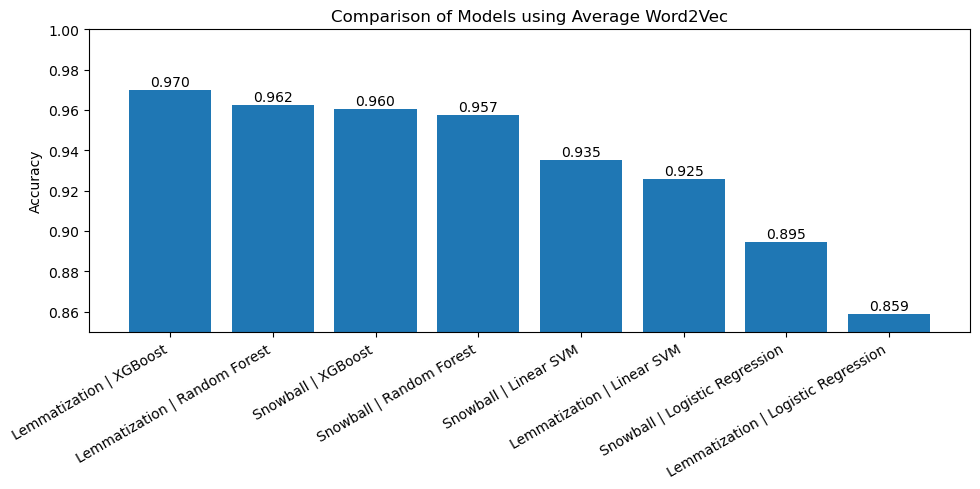

In [74]:
plt.figure(figsize=(10,5))

bars = plt.bar(

    comparison["Preprocessing"] + " | " + comparison["Model"],

    comparison["Accuracy"]

)

plt.xticks(rotation=30, ha="right")

plt.ylabel("Accuracy")

plt.title("Comparison of Models using Average Word2Vec")

plt.ylim(0.85, 1.0)

for bar in bars:

    plt.text(

        bar.get_x() + bar.get_width()/2,

        bar.get_height() + 0.002,

        f"{bar.get_height():.3f}",

        ha="center"

    )

plt.tight_layout()

plt.show()

In [75]:
# ==========================================================
# Additional Evaluation Metrics
# ==========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import time

In [76]:
# ==========================================================
# Evaluate Multiple Machine Learning Models
# ==========================================================

def evaluate_models(models, X_train, X_test, y_train, y_test):

    results = []

    trained_models = {}

    for model_name, model in models.items():

        print("=" * 80)
        print(f"Training Model : {model_name}")
        print("=" * 80)

        # -------------------------------
        # Training
        # -------------------------------
        start_train = time.time()

        model.fit(X_train, y_train)

        end_train = time.time()

        train_time = end_train - start_train

        # -------------------------------
        # Prediction
        # -------------------------------
        start_pred = time.time()

        predictions = model.predict(X_test)

        end_pred = time.time()

        prediction_time = end_pred - start_pred

        # -------------------------------
        # Metrics
        # -------------------------------

        accuracy = accuracy_score(y_test, predictions)

        precision = precision_score(y_test, predictions)

        recall = recall_score(y_test, predictions)

        f1 = f1_score(y_test, predictions)

        # -------------------------------
        # Store Results
        # -------------------------------

        results.append({

            "Model": model_name,

            "Accuracy": round(accuracy,4),

            "Precision": round(precision,4),

            "Recall": round(recall,4),

            "F1 Score": round(f1,4),

            "Training Time (s)": round(train_time,4),

            "Prediction Time (s)": round(prediction_time,4)

        })

        trained_models[model_name] = model

        # -------------------------------
        # Display
        # -------------------------------

        print(f"Accuracy  : {accuracy:.4f}")

        print(f"Precision : {precision:.4f}")

        print(f"Recall    : {recall:.4f}")

        print(f"F1 Score  : {f1:.4f}")

        print()

        print("Confusion Matrix")

        print(confusion_matrix(y_test, predictions))

        print()

        print("Classification Report")

        print(classification_report(y_test, predictions))

        print()

    results_df = pd.DataFrame(results)

    return results_df, trained_models

In [77]:
stem_results, stem_models = evaluate_models(

    models,

    X_train_stem,

    X_test_stem,

    y_train_stem,

    y_test_stem

)

stem_results

Training Model : Logistic Regression
Accuracy  : 0.8946
Precision : 0.5579
Recall    : 0.8092
F1 Score  : 0.6604

Confusion Matrix
[[819  84]
 [ 25 106]]

Classification Report
              precision    recall  f1-score   support

           0       0.97      0.91      0.94       903
           1       0.56      0.81      0.66       131

    accuracy                           0.89      1034
   macro avg       0.76      0.86      0.80      1034
weighted avg       0.92      0.89      0.90      1034


Training Model : Linear SVM
Accuracy  : 0.9352
Precision : 0.6975
Recall    : 0.8626
F1 Score  : 0.7713

Confusion Matrix
[[854  49]
 [ 18 113]]

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.95      0.96       903
           1       0.70      0.86      0.77       131

    accuracy                           0.94      1034
   macro avg       0.84      0.90      0.87      1034
weighted avg       0.94      0.94      0.94      1034



,Model,Accuracy,Precision,Recall,F1 Score,Training Time (s),Prediction Time (s)
0,Logistic Regression,0.8946,0.5579,0.8092,0.6604,0.0072,0.0001
1,Linear SVM,0.9352,0.6975,0.8626,0.7713,0.0175,0.0004
2,Random Forest,0.9574,0.9485,0.7023,0.8070,1.9659,0.0130
3,XGBoost,0.9603,0.8947,0.7786,0.8327,0.3983,0.0007


In [78]:
lemma_results, lemma_models = evaluate_models(

    models,

    X_train_lemma,

    X_test_lemma,

    y_train_lemma,

    y_test_lemma

)

lemma_results

Training Model : Logistic Regression
Accuracy  : 0.8588
Precision : 0.4661
Recall    : 0.7863
F1 Score  : 0.5852

Confusion Matrix
[[785 118]
 [ 28 103]]

Classification Report
              precision    recall  f1-score   support

           0       0.97      0.87      0.91       903
           1       0.47      0.79      0.59       131

    accuracy                           0.86      1034
   macro avg       0.72      0.83      0.75      1034
weighted avg       0.90      0.86      0.87      1034


Training Model : Linear SVM
Accuracy  : 0.9255
Precision : 0.6588
Recall    : 0.8550
F1 Score  : 0.7442

Confusion Matrix
[[845  58]
 [ 19 112]]

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.94      0.96       903
           1       0.66      0.85      0.74       131

    accuracy                           0.93      1034
   macro avg       0.82      0.90      0.85      1034
weighted avg       0.94      0.93      0.93      1034



,Model,Accuracy,Precision,Recall,F1 Score,Training Time (s),Prediction Time (s)
0,Logistic Regression,0.8588,0.4661,0.7863,0.5852,0.0081,0.0001
1,Linear SVM,0.9255,0.6588,0.8550,0.7442,0.0164,0.0002
2,Random Forest,0.9623,0.9694,0.7252,0.8297,2.0213,0.0133
3,XGBoost,0.9700,0.9386,0.8168,0.8735,0.4176,0.0008


In [79]:
stem_results["Preprocessing"] = "Snowball"

lemma_results["Preprocessing"] = "Lemmatization"

In [80]:
comparison = pd.concat(

    [stem_results, lemma_results],

    ignore_index=True

)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,Training Time (s),Prediction Time (s),Preprocessing
0,Logistic Regression,0.8946,0.5579,0.8092,0.6604,0.0072,0.0001,Snowball
1,Linear SVM,0.9352,0.6975,0.8626,0.7713,0.0175,0.0004,Snowball
2,Random Forest,0.9574,0.9485,0.7023,0.8070,1.9659,0.0130,Snowball
3,XGBoost,0.9603,0.8947,0.7786,0.8327,0.3983,0.0007,Snowball
4,Logistic Regression,0.8588,0.4661,0.7863,0.5852,0.0081,0.0001,Lemmatization
5,Linear SVM,0.9255,0.6588,0.8550,0.7442,0.0164,0.0002,Lemmatization
6,Random Forest,0.9623,0.9694,0.7252,0.8297,2.0213,0.0133,Lemmatization
7,XGBoost,0.9700,0.9386,0.8168,0.8735,0.4176,0.0008,Lemmatization


In [81]:
comparison = pd.concat(

    [stem_results, lemma_results],

    ignore_index=True

)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,Training Time (s),Prediction Time (s),Preprocessing
0,Logistic Regression,0.8946,0.5579,0.8092,0.6604,0.0072,0.0001,Snowball
1,Linear SVM,0.9352,0.6975,0.8626,0.7713,0.0175,0.0004,Snowball
2,Random Forest,0.9574,0.9485,0.7023,0.8070,1.9659,0.0130,Snowball
3,XGBoost,0.9603,0.8947,0.7786,0.8327,0.3983,0.0007,Snowball
4,Logistic Regression,0.8588,0.4661,0.7863,0.5852,0.0081,0.0001,Lemmatization
5,Linear SVM,0.9255,0.6588,0.8550,0.7442,0.0164,0.0002,Lemmatization
6,Random Forest,0.9623,0.9694,0.7252,0.8297,2.0213,0.0133,Lemmatization
7,XGBoost,0.9700,0.9386,0.8168,0.8735,0.4176,0.0008,Lemmatization


In [82]:
best_model = comparison.loc[
    comparison["Accuracy"].idxmax()
]

print("=" * 80)
print("🏆 Best Model")
print("=" * 80)

print(f"Preprocessing  : {best_model['Preprocessing']}")
print(f"Model          : {best_model['Model']}")
print(f"Accuracy       : {best_model['Accuracy']:.4f}")
print(f"Precision      : {best_model['Precision']:.4f}")
print(f"Recall         : {best_model['Recall']:.4f}")
print(f"F1 Score       : {best_model['F1 Score']:.4f}")
print(f"Training Time  : {best_model['Training Time (s)']:.4f} seconds")
print(f"Prediction Time: {best_model['Prediction Time (s)']:.4f} seconds")

🏆 Best Model
Preprocessing  : Lemmatization
Model          : XGBoost
Accuracy       : 0.9700
Precision      : 0.9386
Recall         : 0.8168
F1 Score       : 0.8735
Training Time  : 0.4176 seconds
Prediction Time: 0.0008 seconds
